<a href="https://colab.research.google.com/github/salianvikram/Predictive-Indoor-Outdoor-Air-Quality-Control-System/blob/main/LSTM_PM2_5%2C_PM10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.20.0
Go to Runtime → Change runtime type → T4 GPU

Dataset: (1048575, 4)

Train: (876680, 25)
Test : (171870, 25)

Creating sequences...
X_train: (876668, 12, 21)
X_test : (171858, 12, 21)




/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 32)         │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,337 (40.38 KB)

 Trainable params: 10,337 (40.38 KB)

 Non-trainable params: 0 (0.00 B)


Starting FAST LSTM training...
Epoch 1/12
1542/1542 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - loss: 0.3849 - mae: 0.4223 - val_loss: 0.3900 - val_mae: 0.4170
Epoch 2/12
1542/1542 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - loss: 0.3709 - mae: 0.4108 - val_loss: 0.3982 - val_mae: 0.4348
Epoch 3/12
1542/1542 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - loss: 0.3680 - mae: 0.4087 - val_loss: 0.3928 - val_mae: 0.4354
Epoch 4/12
1542/1542 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - loss: 0.3662 - mae: 0.4074 - val_loss: 0.3920 - val_mae: 0.4291
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Predicting...
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


       FAST LSTM MODEL PERFORMANCE
MAE  : 50.3193
MSE  : 4407.1973
RMSE : 66.3867
R²   : 0.5722


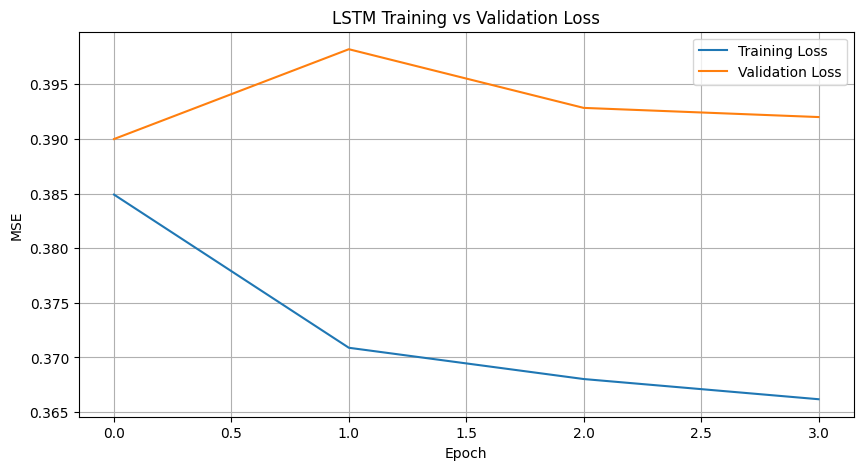

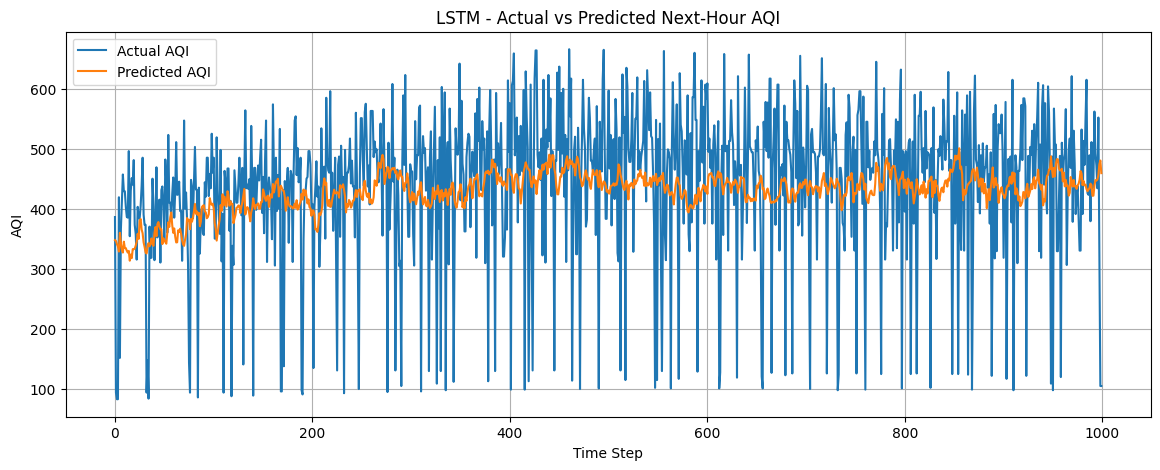

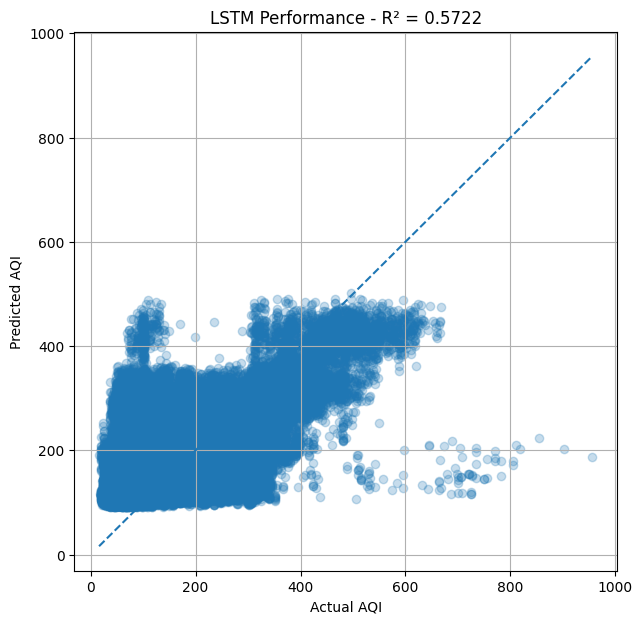



FAST LSTM COMPLETED
Model saved:
/content/AQI_LSTM_FAST.keras

Feature scaler saved:
/content/AQI_LSTM_FAST_Feature_Scaler.pkl

Target scaler saved:
/content/AQI_LSTM_FAST_Target_Scaler.pkl

Feature list saved:
/content/AQI_LSTM_FAST_Features.pkl

Training completed successfully.


7155

In [2]:
# ============================================================
# FAST LSTM MODEL - AQI NEXT-HOUR PREDICTION
# Designed for Google Colab / Large Dataset
# ============================================================

import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. GPU CHECK
# ============================================================

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus)
else:
    print("WARNING: GPU NOT DETECTED")
    print("Go to Runtime → Change runtime type → T4 GPU")


# ============================================================
# 2. MEMORY CLEANUP
# ============================================================

tf.keras.backend.clear_session()
gc.collect()


# ============================================================
# 3. LOAD DATA
# ============================================================

FILE_PATH = "/content/station_hour_pm_aqi.csv"

df = pd.read_csv(
    FILE_PATH,
    dtype={
        "PM2.5": "float32",
        "PM10": "float32",
        "AQI": "float32"
    }
)

print("\nDataset:", df.shape)


# ============================================================
# 4. DATETIME
# ============================================================

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce",
    dayfirst=True
)

df = df.dropna(
    subset=["Datetime"]
)

df = df.sort_values(
    "Datetime"
).reset_index(drop=True)


# ============================================================
# 5. MISSING VALUES
# ============================================================

for col in ["PM2.5", "PM10", "AQI"]:

    df[col] = (
        df[col]
        .ffill()
        .bfill()
    )


# ============================================================
# 6. TIME FEATURES
# ============================================================

df["Hour"] = (
    df["Datetime"]
    .dt.hour
    .astype("int8")
)

df["DayOfWeek"] = (
    df["Datetime"]
    .dt.dayofweek
    .astype("int8")
)

df["Month"] = (
    df["Datetime"]
    .dt.month
    .astype("int8")
)

df["Year"] = (
    df["Datetime"]
    .dt.year
    .astype("int16")
)

df["Hour_Sin"] = np.sin(
    2 * np.pi * df["Hour"] / 24
).astype("float32")

df["Hour_Cos"] = np.cos(
    2 * np.pi * df["Hour"] / 24
).astype("float32")

df["Month_Sin"] = np.sin(
    2 * np.pi * df["Month"] / 12
).astype("float32")

df["Month_Cos"] = np.cos(
    2 * np.pi * df["Month"] / 12
).astype("float32")


# ============================================================
# 7. ESSENTIAL LAG FEATURES
# ============================================================

# Reduced from [1,3,6,12,24]
# to only the most useful lags.

for lag in [1, 6, 24]:

    df[f"PM25_Lag_{lag}"] = (
        df["PM2.5"]
        .shift(lag)
    )

    df[f"PM10_Lag_{lag}"] = (
        df["PM10"]
        .shift(lag)
    )

    df[f"AQI_Lag_{lag}"] = (
        df["AQI"]
        .shift(lag)
    )


# ============================================================
# 8. ROLLING FEATURES
# ============================================================

df["PM25_Roll_6"] = (
    df["PM2.5"]
    .shift(1)
    .rolling(6)
    .mean()
)

df["PM10_Roll_6"] = (
    df["PM10"]
    .shift(1)
    .rolling(6)
    .mean()
)

df["AQI_Roll_6"] = (
    df["AQI"]
    .shift(1)
    .rolling(6)
    .mean()
)


# ============================================================
# 9. NEXT-HOUR TARGET
# ============================================================

df["AQI_Next_Hour"] = (
    df["AQI"]
    .shift(-1)
)


# ============================================================
# 10. REMOVE NaN
# ============================================================

df = (
    df
    .dropna()
    .reset_index(drop=True)
)


# ============================================================
# 11. FEATURES
# ============================================================

FEATURES = [

    "PM2.5",
    "PM10",

    "Hour",
    "DayOfWeek",
    "Month",

    "Hour_Sin",
    "Hour_Cos",
    "Month_Sin",
    "Month_Cos",

    "PM25_Lag_1",
    "PM25_Lag_6",
    "PM25_Lag_24",

    "PM10_Lag_1",
    "PM10_Lag_6",
    "PM10_Lag_24",

    "AQI_Lag_1",
    "AQI_Lag_6",
    "AQI_Lag_24",

    "PM25_Roll_6",
    "PM10_Roll_6",
    "AQI_Roll_6"
]

TARGET = "AQI_Next_Hour"


# ============================================================
# 12. CHRONOLOGICAL SPLIT
# ============================================================

train_df = df[
    df["Year"] < 2020
].copy()

test_df = df[
    df["Year"] >= 2020
].copy()


print("\nTrain:", train_df.shape)
print("Test :", test_df.shape)


# ============================================================
# 13. CREATE NUMPY ARRAYS
# ============================================================

X_train_raw = train_df[
    FEATURES
].values.astype("float32")

y_train_raw = train_df[
    TARGET
].values.astype("float32").reshape(-1, 1)

X_test_raw = test_df[
    FEATURES
].values.astype("float32")

y_test_raw = test_df[
    TARGET
].values.astype("float32").reshape(-1, 1)


# ============================================================
# 14. SCALING
# ============================================================

feature_scaler = StandardScaler()

target_scaler = StandardScaler()


X_train_scaled = (
    feature_scaler
    .fit_transform(X_train_raw)
    .astype("float32")
)

X_test_scaled = (
    feature_scaler
    .transform(X_test_raw)
    .astype("float32")
)


y_train_scaled = (
    target_scaler
    .fit_transform(y_train_raw)
    .astype("float32")
)

y_test_scaled = (
    target_scaler
    .transform(y_test_raw)
    .astype("float32")
)


# ============================================================
# 15. FREE MEMORY
# ============================================================

del X_train_raw
del X_test_raw
del y_train_raw
del y_test_raw

del train_df
del test_df

gc.collect()


# ============================================================
# 16. CREATE SHORTER LSTM SEQUENCES
# ============================================================

TIME_STEPS = 12


def make_sequences(X, y, steps):

    n = len(X) - steps

    X_seq = np.empty(
        (
            n,
            steps,
            X.shape[1]
        ),
        dtype="float32"
    )

    y_seq = np.empty(
        (n, 1),
        dtype="float32"
    )

    for i in range(n):

        X_seq[i] = X[
            i:i + steps
        ]

        y_seq[i] = y[
            i + steps
        ]

    return X_seq, y_seq


print("\nCreating sequences...")


X_train, y_train = make_sequences(
    X_train_scaled,
    y_train_scaled,
    TIME_STEPS
)

X_test, y_test = make_sequences(
    X_test_scaled,
    y_test_scaled,
    TIME_STEPS
)


print(
    "X_train:",
    X_train.shape
)

print(
    "X_test :",
    X_test.shape
)


# ============================================================
# 17. DELETE UNUSED ARRAYS
# ============================================================

del X_train_scaled
del X_test_scaled
del y_train_scaled
del y_test_scaled

gc.collect()


# ============================================================
# 18. BUILD FAST LSTM
# ============================================================

model = Sequential([

    LSTM(
        32,
        return_sequences=True,
        input_shape=(
            TIME_STEPS,
            len(FEATURES)
        )
    ),

    Dropout(0.15),

    LSTM(
        16
    ),

    Dropout(0.15),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])


# ============================================================
# 19. COMPILE
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=["mae"]

)


print("\n")
model.summary()


# ============================================================
# 20. EARLY STOPPING
# ============================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)


# ============================================================
# 21. TRAIN
# ============================================================

print("\nStarting FAST LSTM training...")

history = model.fit(

    X_train,

    y_train,

    epochs=12,

    batch_size=512,

    validation_split=0.10,

    callbacks=[
        early_stop
    ],

    verbose=1
)


# ============================================================
# 22. PREDICT
# ============================================================

print("\nPredicting...")

y_pred_scaled = model.predict(

    X_test,

    batch_size=512,

    verbose=1
)


# ============================================================
# 23. CONVERT BACK TO AQI
# ============================================================

y_pred = (
    target_scaler
    .inverse_transform(
        y_pred_scaled
    )
    .flatten()
)

y_actual = (
    target_scaler
    .inverse_transform(
        y_test
    )
    .flatten()
)


# ============================================================
# 24. METRICS
# ============================================================

mae = mean_absolute_error(
    y_actual,
    y_pred
)

mse = mean_squared_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_actual,
    y_pred
)


# ============================================================
# 25. DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("       FAST LSTM MODEL PERFORMANCE")
print("=" * 60)

print(
    f"MAE  : {mae:.4f}"
)

print(
    f"MSE  : {mse:.4f}"
)

print(
    f"RMSE : {rmse:.4f}"
)

print(
    f"R²   : {r2:.4f}"
)

print("=" * 60)


# ============================================================
# 26. LOSS GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.title(
    "LSTM Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 27. ACTUAL VS PREDICTED
# ============================================================

N = min(
    1000,
    len(y_actual)
)

plt.figure(figsize=(14, 5))

plt.plot(
    y_actual[:N],
    label="Actual AQI"
)

plt.plot(
    y_pred[:N],
    label="Predicted AQI"
)

plt.xlabel("Time Step")

plt.ylabel("AQI")

plt.title(
    "LSTM - Actual vs Predicted Next-Hour AQI"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 28. SCATTER PLOT
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.25
)

low = min(
    y_actual.min(),
    y_pred.min()
)

high = max(
    y_actual.max(),
    y_pred.max()
)

plt.plot(
    [low, high],
    [low, high],
    linestyle="--"
)

plt.xlabel("Actual AQI")

plt.ylabel("Predicted AQI")

plt.title(
    f"LSTM Performance - R² = {r2:.4f}"
)

plt.grid(True)

plt.show()


# ============================================================
# 29. SAVE MODEL
# ============================================================

model.save(
    "/content/AQI_LSTM_FAST.keras"
)

joblib.dump(
    feature_scaler,
    "/content/AQI_LSTM_FAST_Feature_Scaler.pkl"
)

joblib.dump(
    target_scaler,
    "/content/AQI_LSTM_FAST_Target_Scaler.pkl"
)

joblib.dump(
    FEATURES,
    "/content/AQI_LSTM_FAST_Features.pkl"
)


# ============================================================
# 30. FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 60)
print("FAST LSTM COMPLETED")
print("=" * 60)

print("Model saved:")
print("/content/AQI_LSTM_FAST.keras")

print("\nFeature scaler saved:")
print("/content/AQI_LSTM_FAST_Feature_Scaler.pkl")

print("\nTarget scaler saved:")
print("/content/AQI_LSTM_FAST_Target_Scaler.pkl")

print("\nFeature list saved:")
print("/content/AQI_LSTM_FAST_Features.pkl")

print("\nTraining completed successfully.")

gc.collect()